# Step 1: Environment Setup & Dataset Download
## Attention-CNN-LSTM for Intrusion Detection (Bot-IoT Dataset)

This notebook will:
1. Verify your environment (Python, PyTorch, CUDA)
2. Install all required libraries
3. Guide you to download the Bot-IoT dataset
4. Do a quick sanity check on the data

> **Run each cell one by one. Read the output before moving to the next.**

---
## Cell 1: Check Python Version
We need Python 3.8 or higher.

In [45]:
import sys
print(f"Python version: {sys.version}")
assert sys.version_info >= (3, 8), "Please upgrade to Python 3.8 or higher!"
print("✅ Python version is OK")

Python version: 3.12.13 (main, May 10 2026, 19:35:37) [MSC v.1944 64 bit (AMD64)]
✅ Python version is OK


---
## Cell 2: Install Required Libraries
Run this cell to install everything needed for the project.

> **Note:** If you already have these installed, this will just confirm versions. It may take 2-3 minutes.

In [46]:
# Install all required packages
# Run this cell once. After installation, you won't need to run it again.

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 -q
!pip install pandas numpy scikit-learn matplotlib seaborn tqdm fastparquet -q

print("\n✅ All packages installed successfully")

ERROR: Could not find a version that satisfies the requirement torch (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\BA\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torch



✅ All packages installed successfully



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\BA\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


---
## Cell 3: Verify PyTorch and CUDA (GPU)
This confirms your GPU is accessible by PyTorch.

In [47]:
import torch

print(f"PyTorch version     : {torch.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU name            : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version        : {torch.version.cuda}")
    print(f"GPU memory (GB)     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
    device = torch.device('cuda')
    print("\n✅ GPU is ready! Training will be fast.")
else:
    device = torch.device('cpu')
    print("\n⚠️  GPU not detected. Will use CPU (slower but works).")
    print("   If you have an NVIDIA GPU, make sure CUDA drivers are installed.")
    print("   Download: https://developer.nvidia.com/cuda-downloads")

print(f"\nUsing device: {device}")

PyTorch version     : 2.6.0+cu124
CUDA available      : True
GPU name            : NVIDIA GeForce GTX 1050
CUDA version        : 12.4
GPU memory (GB)     : 4.29

✅ GPU is ready! Training will be fast.

Using device: cuda


---
## Cell 4: Import All Libraries
If any import fails, re-run Cell 2 to reinstall.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import os
import warnings
warnings.filterwarnings('ignore')

print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("torch      :", torch.__version__)
print("sklearn    : OK")
print("matplotlib : OK")
print("\n✅ All imports successful!")

pandas     : 3.0.3
numpy      : 2.4.4
torch      : 2.6.0+cu124
sklearn    : OK
matplotlib : OK

✅ All imports successful!


---
## Cell 5: Create Project Folder Structure
This creates organized folders for your project.

In [49]:
import os

# Define folder structure
folders = [
    '../data/raw',        # Raw downloaded dataset goes here
    '../data/processed',  # Cleaned and preprocessed data
    '../models',          # Saved model checkpoints
    '../results',         # Plots, confusion matrices, metrics
    '../notebooks'        # All your notebooks
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ Created: {folder}/")

print("\n📁 Project structure ready!")
print("""
project/
├── data/
│   ├── raw/          ← Put downloaded Bot-IoT CSV files here
│   └── processed/    ← Cleaned data will be saved here
├── models/           ← Trained model will be saved here
├── results/          ← Plots and evaluation results
└── notebooks/        ← All notebooks
""")

✅ Created: data/raw/
✅ Created: data/processed/
✅ Created: models/
✅ Created: results/
✅ Created: notebooks/

📁 Project structure ready!

project/
├── data/
│   ├── raw/          ← Put downloaded Bot-IoT CSV files here
│   └── processed/    ← Cleaned data will be saved here
├── models/           ← Trained model will be saved here
├── results/          ← Plots and evaluation results
└── notebooks/        ← All notebooks



---
## Cell 6: Download Instructions for Bot-IoT Dataset

The Bot-IoT dataset is hosted by the University of New South Wales (UNSW).
It is free but requires manual download from their website.

### Steps to Download:

1. Go to: **https://research.unsw.edu.au/projects/bot-iot-dataset**
2. Scroll down and click **"Download Dataset"**
3. You will be asked to fill a short form (name, email, institution)
4. Download the **"CSV files (Feature Extracted)"** version — NOT the raw PCAP files
5. Extract the ZIP file
6. You will get multiple CSV files like:
   - `UNSW_2018_IoT_Botnet_Full5pc_1.csv`
   - `UNSW_2018_IoT_Botnet_Full5pc_2.csv`
   - ... (multiple parts)
7. **Copy ALL CSV files into the `../data/raw/` folder** you just created above

> **Note:** The full dataset is ~2.5 million records. 
> For initial experimentation, we will use the **5% sample** files which are much more manageable.
> The 5% sample files are named: `UNSW_2018_IoT_Botnet_Full5pc_X.csv`

Run the next cell AFTER you have placed the CSV files in `../data/raw/`

In [50]:
# Run this cell AFTER placing CSV files in ../data/raw/

raw_path = '../data/raw/'
csv_files = [f for f in os.listdir(raw_path) if f.endswith('.csv')]

if len(csv_files) == 0:
    print("❌ No CSV files found in ../data/raw/")
    print("   Please download the dataset and place CSV files in ../data/raw/")
    print("   Follow the instructions in Cell 6 above.")
else:
    print(f"✅ Found {len(csv_files)} CSV file(s) in ../data/raw/:")
    total_size = 0
    for f in csv_files:
        size_mb = os.path.getsize(os.path.join(raw_path, f)) / 1e6
        total_size += size_mb
        print(f"   📄 {f} ({size_mb:.1f} MB)")
    print(f"\n   Total size: {total_size:.1f} MB")

✅ Found 4 CSV file(s) in data/raw/:
   📄 UNSW_2018_IoT_Botnet_Dataset_1.csv (243.0 MB)
   📄 UNSW_2018_IoT_Botnet_Dataset_2.csv (243.2 MB)
   📄 UNSW_2018_IoT_Botnet_Dataset_3.csv (224.3 MB)
   📄 UNSW_2018_IoT_Botnet_Dataset_4.csv (224.8 MB)

   Total size: 935.3 MB


---
## Cell 7: Load and Inspect the Dataset
Let's take a first look at what the data looks like.

In [51]:
# Load column names from the feature names CSV (35 columns matching actual CSV structure)
raw_path = '../data/raw/'
feat_names_path = '../data/raw/OneDrive_1_5-18-2026/UNSW_2018_IoT_Botnet_Dataset_Feature_Names.csv'

feat_df = pd.read_csv(feat_names_path, nrows=0)
column_names = [c.strip() for c in feat_df.columns.tolist()]
print(f"Loaded {len(column_names)} column names: {column_names}")

csv_files = sorted([f for f in os.listdir(raw_path) if f.endswith('.csv')])
print(f"\nLoading {len(csv_files)} CSV files...")
dfs = []
for f in csv_files:
    print(f"  Loading {f}...")
    df_temp = pd.read_csv(
        os.path.join(raw_path, f),
        header=None,
        names=column_names,
        low_memory=False
    )
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
print(f"\n✅ Dataset loaded!")
print(f"   Total rows    : {df.shape[0]:,}")
print(f"   Total columns : {df.shape[1]}")

Loaded 35 column names: ['pkSeqID', 'stime', 'flgs', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'pkts', 'bytes', 'state', 'ltime', 'seq', 'dur', 'mean', 'stddev', 'smac', 'dmac', 'sum', 'min', 'max', 'soui', 'doui', 'sco', 'dco', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'attack', 'category', 'subcategory']

Loading 4 CSV files...
  Loading UNSW_2018_IoT_Botnet_Dataset_1.csv...
  Loading UNSW_2018_IoT_Botnet_Dataset_2.csv...
  Loading UNSW_2018_IoT_Botnet_Dataset_3.csv...
  Loading UNSW_2018_IoT_Botnet_Dataset_4.csv...

✅ Dataset loaded!
   Total rows    : 4,000,000
   Total columns : 35


In [52]:
# Preview the first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,1,1.526344e+09,e,arp,192.168.100.1,NaN,192.168.100.3,NaN,4,240,...,2,2,120,120,0.002508,0.000836,0.000836,0,Normal,Normal
1,2,1.526344e+09,e,tcp,192.168.100.7,139,192.168.100.4,36390,10,680,...,5,5,350,330,0.006190,0.002751,0.002751,0,Normal,Normal
2,3,1.526344e+09,e,udp,192.168.100.149,51838,27.124.125.250,123,2,180,...,1,1,90,90,20.590960,0.000000,0.000000,0,Normal,Normal
3,4,1.526344e+09,e,arp,192.168.100.4,NaN,192.168.100.7,NaN,10,510,...,5,5,210,300,0.006189,0.002751,0.002751,0,Normal,Normal
4,5,1.526344e+09,e,udp,192.168.100.27,58999,192.168.100.1,53,4,630,...,2,2,174,456,0.005264,0.001755,0.001755,0,Normal,Normal


In [53]:
# Check column names
print("All column names:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")

All column names:
   1. pkSeqID
   2. stime
   3. flgs
   4. proto
   5. saddr
   6. sport
   7. daddr
   8. dport
   9. pkts
  10. bytes
  11. state
  12. ltime
  13. seq
  14. dur
  15. mean
  16. stddev
  17. smac
  18. dmac
  19. sum
  20. min
  21. max
  22. soui
  23. doui
  24. sco
  25. dco
  26. spkts
  27. dpkts
  28. sbytes
  29. dbytes
  30. rate
  31. srate
  32. drate
  33. attack
  34. category
  35. subcategory


In [54]:
# Check data types and missing values
print("Data info:")
print(df.dtypes)
print(f"\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  No missing values! ✅")

Data info:
pkSeqID          int64
stime          float64
flgs               str
proto              str
saddr              str
sport           object
daddr              str
dport           object
pkts             int64
bytes            int64
state              str
ltime          float64
seq              int64
dur            float64
mean           float64
stddev         float64
smac           float64
dmac           float64
sum            float64
min            float64
max            float64
soui           float64
doui           float64
sco            float64
dco            float64
spkts            int64
dpkts            int64
sbytes           int64
dbytes           int64
rate           float64
srate          float64
drate          float64
attack           int64
category           str
subcategory        str
dtype: object

Missing values per column:
sport        945
dport        945
smac     4000000
dmac     4000000
soui     4000000
doui     4000000
sco      4000000
dco      4000000
dtype:

In [55]:
label_cols = ['attack', 'category', 'subcategory']
for col in label_cols:
    if col in df.columns:
        print(f"\nValue counts for '{col}':")
        print(df[col].value_counts())
        print(f"Unique values: {df[col].nunique()}")


Value counts for 'attack':
attack
1    3992861
0       7139
Name: count, dtype: int64
Unique values: 2

Value counts for 'category':
category
DoS               2169635
Reconnaissance    1821639
Normal               7139
Theft                1587
Name: count, dtype: int64
Unique values: 4

Value counts for 'subcategory':
subcategory
TCP                  2139929
Service_Scan         1463364
OS_Fingerprint        358275
HTTP                   29706
Normal                  7139
Keylogging              1469
Data_Exfiltration        118
Name: count, dtype: int64
Unique values: 7


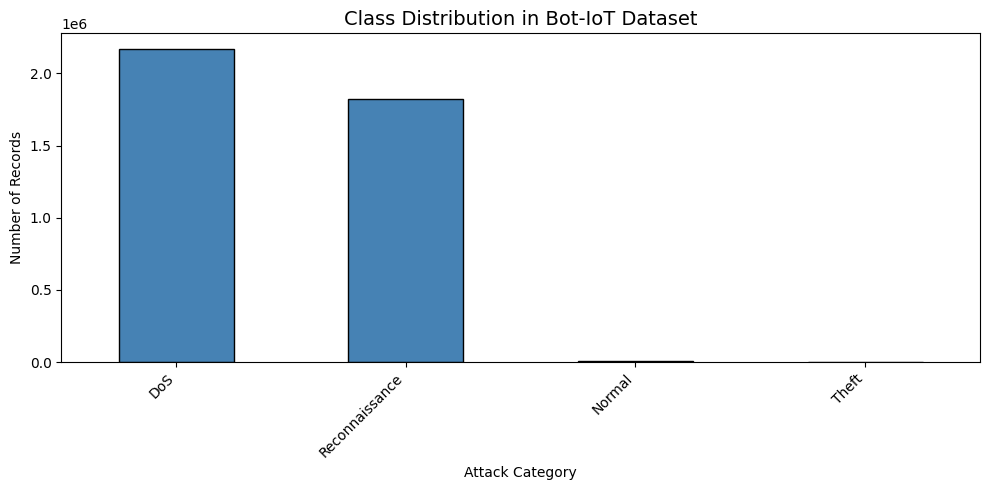

✅ Plot saved to results/class_distribution.png


In [56]:
# Visualize class distribution
LABEL_COL = 'category'

if LABEL_COL in df.columns:
    plt.figure(figsize=(10, 5))
    df[LABEL_COL].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Class Distribution in Bot-IoT Dataset', fontsize=14)
    plt.xlabel('Attack Category')
    plt.ylabel('Number of Records')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../results/class_distribution.png', dpi=150)
    plt.show()
    print("✅ Plot saved to ../results/class_distribution.png")
else:
    print(f"❌ Column '{LABEL_COL}' not found.")

---
## Cell 8: Save Dataset Info for Next Notebook

In [57]:
# Save column names and basic info for reference in next notebooks
info = {
    'total_rows': df.shape[0],
    'total_cols': df.shape[1],
    'columns': list(df.columns),
    'label_col': LABEL_COL,
    'classes': list(df[LABEL_COL].unique()) if LABEL_COL in df.columns else []
}

import json
with open('../data/processed/dataset_info.json', 'w') as f:
    json.dump(info, f, indent=2)

print("✅ Dataset info saved to ../data/processed/dataset_info.json")
print("\n" + "="*50)
print("SETUP COMPLETE! You are ready for Notebook 2.")
print("="*50)
print("""
Summary:
  ✅ Python & PyTorch verified
  ✅ All libraries installed
  ✅ Project folders created
  ✅ Dataset loaded and inspected
  ✅ Class distribution visualized

Next step: Run notebook  →  02_preprocessing.ipynb
""")

✅ Dataset info saved to data/processed/dataset_info.json

SETUP COMPLETE! You are ready for Notebook 2.

Summary:
  ✅ Python & PyTorch verified
  ✅ All libraries installed
  ✅ Project folders created
  ✅ Dataset loaded and inspected
  ✅ Class distribution visualized

Next step: Run notebook  →  02_preprocessing.ipynb



In [ ]:
# sport and dport are port numbers stored as object (mixed int + NaN) — cast to float
df['sport'] = pd.to_numeric(df['sport'], errors='coerce')
df['dport'] = pd.to_numeric(df['dport'], errors='coerce')

# Save full dataset to parquet for fast loading in subsequent notebooks
parquet_path = '../data/processed/botiot_raw.parquet'
df.to_parquet(parquet_path, engine='fastparquet', index=False)
size_mb = os.path.getsize(parquet_path) / 1e6
print(f"✅ Saved to {parquet_path} ({size_mb:.1f} MB)")
print("   Load in next notebooks with: df = pd.read_parquet('../data/processed/botiot_raw.parquet', engine='fastparquet')")

# Free memory — df is no longer needed in this notebook
import gc
del df
gc.collect()

# Release all cached GPU memory
torch.cuda.empty_cache()
print("\n✅ Memory freed.")

✅ Saved to data/processed/botiot_raw.parquet (191.4 MB)
   Load in next notebooks with: df = pd.read_parquet('data/processed/botiot_raw.parquet', engine='fastparquet')

✅ Memory freed.


---
## Troubleshooting Guide

| Problem | Solution |
|--------|----------|
| `ModuleNotFoundError` | Re-run Cell 2 to reinstall libraries |
| `CUDA not available` | Download CUDA from https://developer.nvidia.com/cuda-downloads |
| CSV files not found | Make sure files are in `../data/raw/` folder, not a subfolder |
| Label column not found | Check Cell 7 output and update `LABEL_COL` variable |
| Memory error on loading | Use only 1-2 CSV files instead of all of them |